In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# Define state

class BMIState(TypedDict):
    weight: float  # in kilograms
    height: float  # in meters
    bmi: float     # Body Mass Index
    bmi_label: str # BMI Category Label

In [3]:

# Define the node function
def calculate_bmi(state: BMIState) -> BMIState:
    bmi = state['weight'] / (state['height'] ** 2)
    state['bmi'] = bmi
    return state

In [4]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        label = "Underweight"
    elif 18.5 <= bmi < 24.9:
        label = "Normal weight"
    elif 25 <= bmi < 29.9:
        label = "Overweight"
    else:
        label = "Obesity"
    state['bmi_label'] = label
    return state

In [5]:
# Define the graph
graph = StateGraph(BMIState)

# Add node
graph.add_node("Calculate BMI", calculate_bmi)
graph.add_node("Lebel BMI", label_bmi)

# Add edges
graph.add_edge(START, "Calculate BMI")
graph.add_edge("Calculate BMI", "Lebel BMI")
graph.add_edge("Lebel BMI", END)

# Compile the graph
workflow = graph.compile()

# Initial state
initial_state = {
    "weight": 70.0,  # in kilograms
    "height": 1.75,  # in meters
    "bmi": 0.0,       # will be updated
    "bmi_label": ""     # will be updated
}

# Execute the graph
final_state = workflow.invoke(initial_state)

print(f"Calculated BMI: {final_state}")

Calculated BMI: {'weight': 70.0, 'height': 1.75, 'bmi': 22.857142857142858, 'bmi_label': 'Normal weight'}


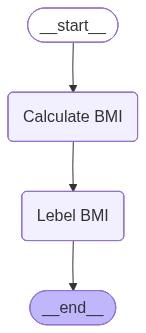

In [6]:
from IPython.display import Image

# Visualize the graph
Image(workflow.get_graph().draw_mermaid_png())